In [20]:
#Basic import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#modelling 
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Import the CSV Data as pandas dataframe   

In [2]:
df = pd.read_csv('Telco_customer_churn.csv')

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
x = df.drop([
    'CustomerID',
    'Churn Label',
    'Churn Score',
    'Churn Reason',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'CLTV'
], axis=1, inplace=True)

In [5]:
y = df['Churn Value']

In [15]:


df['Total Charges'] = pd.to_numeric(df['Total Charges'],errors='coerce')
cat_columns = df.select_dtypes(include = object).columns
cat_columns

C:\Users\Bhavesh\AppData\Local\Temp\ipykernel_20572\3323243507.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include = object).columns


Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')

In [16]:
df_encoded = pd.get_dummies(df,drop_first=True)
df_encoded.shape

(7043, 31)

In [17]:
X= df_encoded.drop(columns=['Churn Value'])
X


,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,False,False,False,False,True,False,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,True,False,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,False,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,False,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [33]:
from sklearn.model_selection import train_test_split
#seperate dataset into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((5634, 30), (1409, 30))

create an evaluation function to give all metrics after model training  

In [34]:
def evaluate_model(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return accuracy, precision, recall, f1, auc

In [31]:

X.isna().sum()

Tenure Months                             0
Monthly Charges                           0
Total Charges                             0
Gender_Male                               0
Senior Citizen_Yes                        0
Partner_Yes                               0
Dependents_Yes                            0
Phone Service_Yes                         0
Multiple Lines_No phone service           0
Multiple Lines_Yes                        0
Internet Service_Fiber optic              0
Internet Service_No                       0
Online Security_No internet service       0
Online Security_Yes                       0
Online Backup_No internet service         0
Online Backup_Yes                         0
Device Protection_No internet service     0
Device Protection_Yes                     0
Tech Support_No internet service          0
Tech Support_Yes                          0
Streaming TV_No internet service          0
Streaming TV_Yes                          0
Streaming Movies_No internet ser

In [36]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(verbose=False),
    "LightGBM": LGBMClassifier()
}
model_list=[]
results = []

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(verbose=False),
    "LightGBM": LGBMClassifier()
}

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Training Metrics
    train_acc, train_prec, train_rec, train_f1, train_auc = evaluate_model(
        y_train,
        y_train_pred,
        y_train_prob
    )

    # Testing Metrics
    test_acc, test_prec, test_rec, test_f1, test_auc = evaluate_model(
        y_test,
        y_test_pred,
        y_test_prob
    )
    results.append({
    "Model": name,
    "Accuracy": test_acc,
    "F1": test_f1,
    "ROC_AUC": test_auc
    })

    print(f"Model: {name}")
    print("Training Performance")
    print(f"Accuracy : {train_acc:.4f}")
    print(f"Precision: {train_prec:.4f}")
    print(f"Recall   : {train_rec:.4f}")
    print(f"F1 Score : {train_f1:.4f}")
    print(f"ROC-AUC  : {train_auc:.4f}")

    print("-" * 50)

    print("Testing Performance")
    print(f"Accuracy : {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall   : {test_rec:.4f}")
    print(f"F1 Score : {test_f1:.4f}")
    print(f"ROC-AUC  : {test_auc:.4f}")

    print("=" * 50)
    print()

c:\ML Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Training Performance
Accuracy : 0.8172
Precision: 0.6738
Recall   : 0.5793
F1 Score : 0.6230
ROC-AUC  : 0.8594
--------------------------------------------------
Testing Performance
Accuracy : 0.8013
Precision: 0.6840
Recall   : 0.5575
F1 Score : 0.6143
ROC-AUC  : 0.8510

Model: KNN
Training Performance
Accuracy : 0.8351
Precision: 0.7373
Recall   : 0.5711
F1 Score : 0.6437
ROC-AUC  : 0.8905
--------------------------------------------------
Testing Performance
Accuracy : 0.7573
Precision: 0.5960
Recall   : 0.4500
F1 Score : 0.5128
ROC-AUC  : 0.7465

Model: Decision Tree
Training Performance
Accuracy : 0.9977
Precision: 0.9993
Recall   : 0.9918
F1 Score : 0.9956
ROC-AUC  : 1.0000
--------------------------------------------------
Testing Performance
Accuracy : 0.7367
Precision: 0.5365
Recall   : 0.5325
F1 Score : 0.5345
ROC-AUC  : 0.6772

Model: Random Forest
Training Performance
Accuracy : 0.9977
Precision: 0.9939
Recall   : 0.9973
F1 Score : 0.9956
ROC-AUC 

In [42]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1,ROC_AUC
0,Logistic Regression,0.801278,0.614325,0.850960
1,KNN,0.757275,0.512821,0.746511
2,Decision Tree,0.736693,0.534504,0.677151
3,Random Forest,0.790632,0.582744,0.835911
4,AdaBoost,0.806246,0.613861,0.858383
5,Gradient Boosting,0.808375,0.617564,0.861283
6,XGBoost,0.788502,0.591781,0.836394
7,CatBoost,0.804826,0.618585,0.858958
8,LightGBM,0.804116,0.620879,0.853669


In [50]:
#Gradient Boost
gradient_model = GradientBoostingClassifier()
gradient_model = gradient_model.fit(X_train,y_train)
y_pred = gradient_model.predict_proba(X_test)[:, 1]
score= roc_auc_score(y_test,y_pred)
print(f"Accuracy {score:2%}")

Accuracy 86.128345%


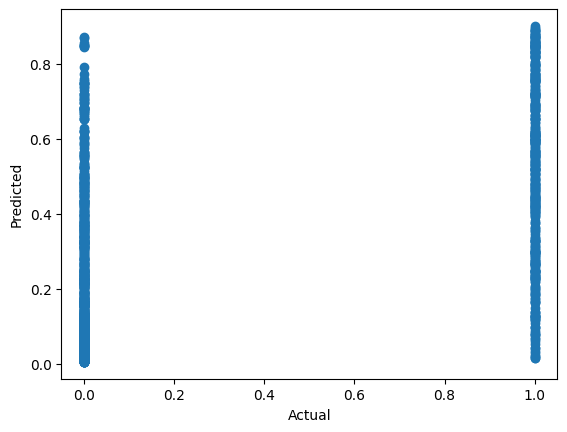

In [51]:
#plot y_pred and y_test
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

<Axes: xlabel='Churn Value'>

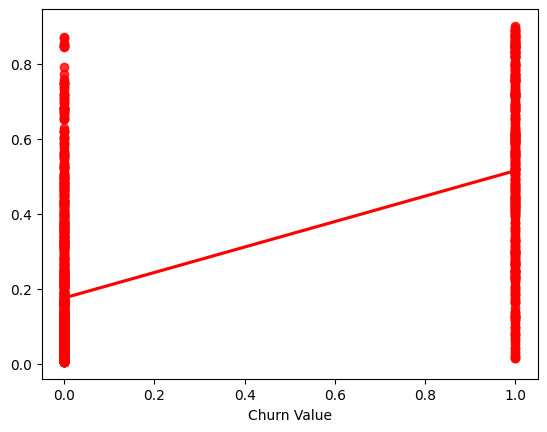

In [ ]:
sns.regplotplot(x=y_test,y=y_pred,ci=None,color="red")

In [53]:
#difference b/w actual and predicted 
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
185,1,0.448487,0.551513
2715,0,0.210269,-0.210269
3825,0,0.223824,-0.223824
1807,1,0.712151,0.287849
132,1,0.360003,0.639997
...,...,...,...
6366,0,0.042895,-0.042895
315,1,0.432091,0.567909
2439,0,0.662540,-0.662540
5002,0,0.036635,-0.036635
